# <center>Instituto Superior de Engenharia de Lisboa</center>
## <center>Mestrado em Engenharia Informática e Multimédia</center>
### <center>Visão Artificial e Realidade Mista</center>
### <center>2025/2026</center>

# <br>
###  <center> Trabalho Prático 1 - Feature Based Face Detection and Recognition for Augmented Reality</center>
# </br>


Trabalho realizado por:
<br>
Miguel Azenha,  nº47708

Docente:
<br>
Professor Pedro Mendes Jorge


## Deteção de Faces



In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import os 
import numpy as np
import mediapipe as mp

In [2]:
# Parametros de mediapipe
BaseOptions = mp.tasks.BaseOptions
VisionRunningMode = mp.tasks.vision.RunningMode
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions

options_video = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="landmarkers/face_landmarker.task"),
    running_mode=VisionRunningMode.VIDEO,
    num_faces=5,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

options_image = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="landmarkers/face_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=5,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
)

landmarker_video = FaceLandmarker.create_from_options(options_video)
landmarker_image = FaceLandmarker.create_from_options(options_image)



In [3]:
def get_faces_landmarks_video(frame, timestamp_ms):
    rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    faces_landmarks = landmarker_video.detect_for_video(mp_image, timestamp_ms).face_landmarks
    return faces_landmarks

def get_faces_landmarks_image(image):
    rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    faces_landmarks = landmarker_image.detect(mp_image).face_landmarks
    return faces_landmarks

In [4]:
def get_face_position(image, face_landmarks, padding=0):
        """
        Recebe uma imagem e uma lista com os pontos(landmarks) de cada face detetada, vai calcular o
        retângulo que envolve cada face e retornar uma lista de cada rectângulo (x,y,w,h) de cada face detectada

        Parâmetros:
        - img: imagem em RGB
        - landmarkers: lista dos pontos das faces
        Retorna:
        - face_positions: lista de rectângulos com valores (x,y,w,h)
        """

        # Caso não sejam detetadas faces, retornar lista vazia
        if not face_landmarks:
                return None

        # Retirar a altura e largura da imagem
        h, w = image.shape[:2]
         
        # xs representa os valores x's dos pontos de referência da face
        # # ys representa os valores y's dos pontos de referência da face					
        xs = [lm.x for lm in face_landmarks]
        ys = [lm.y for lm in face_landmarks]

        # Vamos calcular o retângulo que envolve a face, adicionando um padding de 10% em cada direção
        # (x1,y1) representa o canto superior esquerdo do retângulo
        x1 = int(max(0, (min(xs) - padding) * w))
        y1 = int(max(0, (min(ys) - padding) * h))

        # (x2,y2) representa o canto inferior direito do retângulo
        x2 = int(min(w, (max(xs) + padding) * w))
        y2 = int(min(h, (max(ys) + padding) * h))

        face_position=(x1, y1, x2 - x1, y2 - y1)

        return face_position



def draw_face_rect(img, rect, color=(0, 255, 0)):
        """
        Recebe uma imagem e um retângulo de face detetada e retorna a imagem com o retângulo desenhado.

        Parâmetros:
        - img: imagem em RGB
        - rect: retângulo de face detetada, ex: (x, y, w, h)
        Retorna:
        - new_img: imagem com o retângulo de face detetada desenhado
        """
        new_img = img.copy()

        x, y, w, h = rect[0], rect[1], rect[2], rect[3]
        cv.rectangle(new_img, (x, y), (x + w, y + h), color, 2)

        return new_img



def write_text(img, text, position, size=0.5, color=(0, 255, 0),thickness=1):
        """
        Escreve texto na imagem.

        Parâmetros:
        - img: imagem em RGB
        - text: texto
        - position: posição do texto (x, y)
        - size: tamanho do texto
        - color: cor do texto
        Retorna:
        - new_img: imagem com o texto escrito
        """
        new_img = img.copy()
        cv.putText(new_img, text, position, cv.FONT_HERSHEY_COMPLEX, size, color, thickness)
        return new_img




## Normalização de Faces

In [5]:

def normalize_face(img,face_position, face_landmarks):

        x, y, w, h = face_position
        H, W = img.shape[:2]

        # pontos dos olhos
        left_eye_left_corner = face_landmarks[33]
        left_eye_right_corner = face_landmarks[133]
        right_eye_left_corner = face_landmarks[362]
        right_eye_right_corner = face_landmarks[263]

        # centro de cada olho
        left_eye = (
                int((left_eye_left_corner.x + left_eye_right_corner.x) * W / 2),
                int((left_eye_left_corner.y + left_eye_right_corner.y) * H / 2)
        )

        right_eye = (
                int((right_eye_left_corner.x + right_eye_right_corner.x) * W / 2),
                int((right_eye_left_corner.y + right_eye_right_corner.y) * H / 2)
        )

        # ângulo entre os olhos
        dx = right_eye[0] - left_eye[0]
        dy = right_eye[1] - left_eye[1]
        angle = np.degrees(np.arctan2(dy, dx))

        # centro entre os olhos
        eyes_center = (
                int((left_eye[0] + right_eye[0]) / 2),
                int((left_eye[1] + right_eye[1]) / 2)
        )

        # rotação
        M = cv.getRotationMatrix2D(eyes_center, angle, 1.0)
        aligned = cv.warpAffine(img, M, (W, H))
        
        # crop da face já rodada
        face_aligned = aligned[y:y+h, x:x+w]

        if face_aligned.size == 0:
                return None

        # normalização final
        normalized_face = cv.cvtColor(face_aligned, cv.COLOR_BGR2GRAY)
        # MPEG-7 não desempenha melhor resultados fica melhor 100x100
        normalized_face = cv.resize(normalized_face, (100, 100))
        # Normaliza os valores 
        normalized_face = cv.equalizeHist(normalized_face)

        return normalized_face

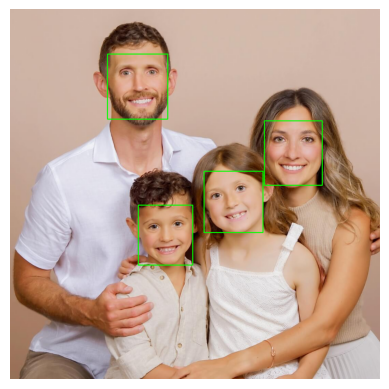

In [6]:
img=cv.imread('imagens\\family_picture.jpg')

faces_landmarks = get_faces_landmarks_image(img)

for face_landmarks in faces_landmarks:
    face_position = get_face_position(img, face_landmarks)
    img = draw_face_rect(img, face_position)

img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.axis(False)
plt.imshow(img)

In [7]:

cap =  cv.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret:
        break

    timestamp_ms = int(cap.get(cv.CAP_PROP_POS_MSEC))
    
    faces_landmarks = get_faces_landmarks_video(frame, timestamp_ms)
    
    for face_landmarks in faces_landmarks:
        face_position = get_face_position(frame, face_landmarks)
        frame = draw_face_rect(frame, face_position)
 
    cv.imshow('Face Detection', frame)

    if cv.waitKey(1) & 0xFF == ord('q'):
        break
    
cap.release()
cv.destroyAllWindows()

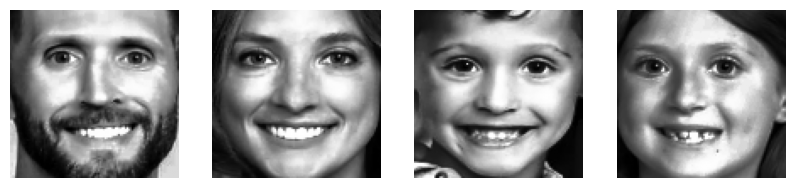

In [8]:
img = cv.imread('imagens\\family_picture.jpg')

faces_landmarks = get_faces_landmarks_image(img)

plt.figure(figsize=(10, 10))

for i in range(len(faces_landmarks)):
    face_position = get_face_position(img, faces_landmarks[i])
    face_norm=normalize_face(img,face_position, faces_landmarks[i])
    plt.subplot(1,len(faces_landmarks) , i +1)
    plt.axis(False)
    plt.imshow(face_norm, cmap='gray')




# Reconhecimento Facial

In [9]:

dataset_treino_dir = "dataset\\treino"
print("Carregando dataset:", dataset_treino_dir)
dataset_treino = os.listdir(dataset_treino_dir)

faces = []
labels = []
label_map = {}

recognizer_parameters = {
    "radius": 1,
    "neighbors": 8,
    "grid_x": 8,
    "grid_y": 8
}

current_label = 0

print("Treinando o modelo...")
for person_name in os.listdir(dataset_treino_dir):
    print(f"Processando {person_name}...")
    person_path = os.path.join(dataset_treino_dir, person_name)

    if not os.path.isdir(person_path):
        continue

    label_map[current_label] = person_name

    num_images=len(os.listdir(person_path))
    detected_faces=0

    for img_name in os.listdir(person_path):

        img_path = os.path.join(person_path, img_name)

        img = cv.imread(img_path)

        faces_landmarks = get_faces_landmarks_image(img)

        if not faces_landmarks:
            continue

        detected_faces+=len(faces_landmarks)

        for face_landmarks in faces_landmarks:
            face_position = get_face_position(img, face_landmarks)
            normalized_face=normalize_face(img,face_position, face_landmarks)

        faces.append(normalized_face)
        labels.append(current_label)

    print(f"Faces detectadas: {detected_faces}/{num_images}")

    current_label += 1

labels = np.array(labels)

recognizer = cv.face.LBPHFaceRecognizer_create(**recognizer_parameters)

recognizer.train(faces, labels)

print("Modelo treinado!")




Carregando dataset: dataset\treino
Treinando o modelo...
Processando chris_evans...
Faces detectadas: 10/10
Processando miguel_azenha...
Faces detectadas: 13/13
Processando pedro_jorge...
Faces detectadas: 10/10
Processando robert_downey...
Faces detectadas: 10/10
Modelo treinado!


Nome: robert_downey, confianca: 89.7222917214439


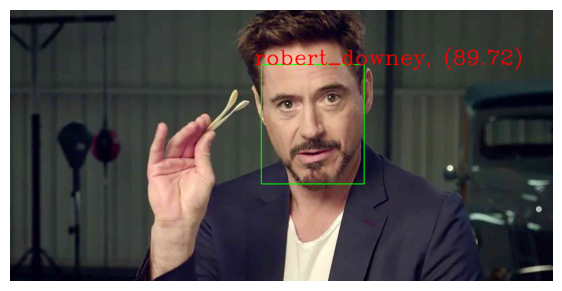

In [10]:
img = cv.imread('dataset\\teste\\robert_downey\\robert_downey10.jpg')

faces_landmarks = get_faces_landmarks_image(img)
plt.figure(figsize=(7, 7))
for face_landmarks in faces_landmarks:
    face_position = get_face_position(img, face_landmarks)
    face_norm = normalize_face(img, face_position, face_landmarks)
    label, confidence = recognizer.predict(face_norm)
    x,y,w,h = face_position
    name = label_map[label]
    print(f"Nome: {name}, confianca: {confidence}")
    img=draw_face_rect(img, face_position)
    text = f"{name}, ({confidence:.2f})"
    img=write_text(img, text, (x-20, y),2,(0,0,255),2)
    
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.axis(False)
plt.imshow(img)

In [ ]:
limite=95
cap =  cv.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret:
        break

    timestamp_ms = int(cap.get(cv.CAP_PROP_POS_MSEC))

    faces_landmarks = get_faces_landmarks_video(frame, timestamp_ms)

    if not faces_landmarks:
        continue

    for face_landmarks in faces_landmarks:
        face_position = get_face_position(frame, face_landmarks)
        face_norm = normalize_face(frame, face_position, face_landmarks)
        label, confidence = recognizer.predict(face_norm)
        x,y,w,h = face_position
        name = label_map[label]
        if confidence > limite:
            name = "Unknown"
        frame=draw_face_rect(frame, face_position)
        text = f"{name} ({confidence:.2f})"
        frame=write_text(frame, text, (x, y),0.7,(255,0,0))
        
    cv.imshow('Face Recognition', frame)
    if cv.waitKey(1) & 0xFF == ord('q'):
        break
    
cap.release()
cv.destroyAllWindows()

## Realidade Aumentada

In [12]:
def get_eyes_AngleAndCenter(img, face_landmarks):
    h, w = img.shape[:2]

    left_eye = face_landmarks[33]
    right_eye = face_landmarks[263]

    lx, ly = int(left_eye.x * w), int(left_eye.y * h)
    rx, ry = int(right_eye.x * w), int(right_eye.y * h)

    angle = -np.degrees(np.arctan2(ry - ly, rx - lx))
    center = ((lx + rx) // 2, (ly + ry) // 2)

    return angle, center

def get_hat_pos(img, face_landmarks,offset=0.05):
    h, w = img.shape[:2]

    head = face_landmarks[10]
    x, y = int(head.x * w), int((head.y-offset) * h)

    return (x, y)
def get_mustache_pos(img, face_landmarks):
    position=(int(face_landmarks[2].x*img.shape[1]),int(face_landmarks[2].y*img.shape[0]))
    return position


def rotate_object(object, angle):
    h, w = object.shape[:2]
    center = (w // 2, h // 2)

    M = cv.getRotationMatrix2D(center, angle, 1.0)

    rotated_object = cv.warpAffine(object, M, (w, h))

    return rotated_object

def resize_object(face_position, object,scale=(1.0,1.0)):
    x,y,w,h = face_position
    w=int(w*scale[0])
    h=int(h*scale[1])
    object=cv.resize(object,(w,h))
    return object


def add_object(frame, obj, position):
    result = frame.copy()
    h, w = obj.shape[:2]
    H, W = result.shape[:2]

    x = position[0] - w // 2
    y = position[1] - h // 2

    x1, y1 = max(0, x), max(0, y)
    x2, y2 = min(W, x + w), min(H, y + h)

    # se não houver interseção, não desenha nada
    if x1 >= x2 or y1 >= y2:
        return result

    ox1, oy1 = x1 - x, y1 - y
    ox2, oy2 = ox1 + (x2 - x1), oy1 + (y2 - y1)

    overlay_crop = obj[oy1:oy2, ox1:ox2]

    # segurança extra
    if overlay_crop.size == 0:
        return result

    roi = result[y1:y2, x1:x2]

    # garantir PNG com alpha
    if len(overlay_crop.shape) < 3 or overlay_crop.shape[2] < 4:
        return result

    bgr = overlay_crop[:, :, :3]
    alpha = overlay_crop[:, :, 3:4] / 255.0

    # segurança extra: shapes têm de coincidir
    if roi.shape[:2] != bgr.shape[:2]:
        return result

    roi[:] = (alpha * bgr + (1 - alpha) * roi).astype(np.uint8)
    return result



robert_downey
Confianca: 89.7222917214439


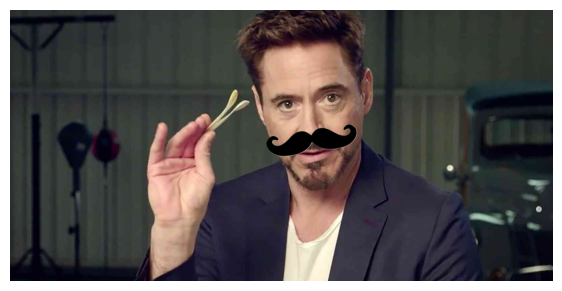

In [15]:
img = cv.imread('dataset\\teste\\robert_downey\\robert_downey10.jpg')
object=cv.imread("imagens\\mustache.png", cv.IMREAD_UNCHANGED)
faces_landmarks = get_faces_landmarks_image(img)
plt.figure(figsize=(7, 7))
for face_landmarks in faces_landmarks:
    face_position = get_face_position(img, face_landmarks)
    face_norm = normalize_face(img, face_position, face_landmarks)
    label, confidence = recognizer.predict(face_norm)
    name = label_map[label]

    if name == 'robert_downey':
        print(name)
        print(f"Confianca: {confidence}")
        angle, center = get_eyes_AngleAndCenter(img, face_landmarks)
        object = resize_object(face_position,object,(1,0.4))
        rotated_object = rotate_object(object, angle)
        position=get_mustache_pos(img, face_landmarks)
        img = add_object(img, rotated_object, position)

    
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.axis(False)
plt.imshow(img)

In [14]:
hat = cv.imread("imagens\\hat.png", cv.IMREAD_UNCHANGED)
sunglasses = cv.imread("imagens\\sunglasses.png", cv.IMREAD_UNCHANGED)
mustache = cv.imread("imagens\\mustache.png", cv.IMREAD_UNCHANGED)

limite = 155
cap = cv.VideoCapture(0)
while True:
    ret, frame = cap.read()
    if not ret:
        break

    timestamp_ms = int(cap.get(cv.CAP_PROP_POS_MSEC))
    faces_landmarks = get_faces_landmarks_video(frame, timestamp_ms)

    if not faces_landmarks:
        continue

    for face_landmarks in faces_landmarks:
        face_position = get_face_position(frame, face_landmarks)
        x, y, _, _ = face_position
        face_norm = normalize_face(frame, face_position, face_landmarks)
        label, confidence = recognizer.predict(face_norm)
        name = label_map[label]
        frame=write_text(frame, str(confidence), (x, y),0.7,(0,0,255))

        if confidence > 105:
            name = "Unknown"

        angle, center = get_eyes_AngleAndCenter(frame, face_landmarks)
        if name == "miguel_azenha":
            object = sunglasses
            position = center
            object = resize_object(face_position, object,(1.2,1))

        elif name == "pedro_jorge":
            object = hat
            position = get_hat_pos(frame, face_landmarks, 0.05)
            object = resize_object(face_position, object, (1.2, 1))

        else:
            object = mustache
            position = get_mustache_pos(frame, face_landmarks)
            object = resize_object(face_position, object, (1, 0.4))

        rotated_object = rotate_object(object, angle)
        frame = add_object(frame, rotated_object, position)

    cv.imshow("Face Recognition", frame)

    if cv.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv.destroyAllWindows()